In [276]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [277]:
from google.colab import files
uploaded = files.upload()

Saving tokenized_access_logs.csv to tokenized_access_logs (1).csv


In [284]:
df_logs = pd.read_csv(
    'tokenized_access_logs (1).csv',
    low_memory=False
)

print("Dataset loaded successfully.")
print("Shape:", df_logs.shape)

Dataset loaded successfully.
Shape: (469977, 8)


In [285]:
df_logs.head()

df_logs.info()

print(df_logs.isnull().sum())

print("Exact duplicates:", df_logs.duplicated().sum())

print("Exact duplicates:", df_logs.duplicated().sum())

print(df_logs.nunique())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 469977 entries, 0 to 469976
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Product     469977 non-null  object
 1   Category    469977 non-null  object
 2   Date        469977 non-null  object
 3   Month       469977 non-null  object
 4   Hour        469977 non-null  int64 
 5   Department  469977 non-null  object
 6   ip          469977 non-null  object
 7   url         469977 non-null  object
dtypes: int64(1), object(7)
memory usage: 28.7+ MB
Product       0
Category      0
Date          0
Month         0
Hour          0
Department    0
ip            0
url           0
dtype: int64
Exact duplicates: 3249
Exact duplicates: 3249
Product           76
Category          33
Date          160815
Month              5
Hour              24
Department         6
ip              3340
url              152
dtype: int64


In [287]:
logs_clean = df_logs.copy()

logs_clean['DateTime'] = pd.to_datetime(
    logs_clean['Date'],
    errors='coerce'
)

print("Invalid dates:", logs_clean['DateTime'].isnull().sum())

print("Start date:", logs_clean['DateTime'].min())
print("End date:", logs_clean['DateTime'].max())


Invalid dates: 0
Start date: 2017-09-01 06:00:00
End date: 2018-01-31 23:58:00


In [288]:
duplicate_rows = logs_clean[
    logs_clean.duplicated(
        keep=False
    )
]

duplicate_rows.head()



,Product,Category,Date,Month,Hour,Department,ip,url,DateTime
500,Perfect Fitness Perfect Rip Deck,cleats,9/1/2017 9:17,Sep,9,apparel,130.130.149.74,/department/apparel/category/cleats/product/Pe...,2017-09-01 09:17:00
502,Perfect Fitness Perfect Rip Deck,cleats,9/1/2017 9:17,Sep,9,apparel,130.130.149.74,/department/apparel/category/cleats/product/Pe...,2017-09-01 09:17:00
2292,adidas Men's Germany Black Crest Away Tee,girls' apparel,9/1/2017 20:46,Sep,20,golf,128.172.111.205,/department/golf/category/girls'%20apparel/pro...,2017-09-01 20:46:00
2293,adidas Men's Germany Black Crest Away Tee,girls' apparel,9/1/2017 20:46,Sep,20,golf,128.172.111.205,/department/golf/category/girls'%20apparel/pro...,2017-09-01 20:46:00
10089,adidas Kids' RG III Mid Football Cleat,featured shops,9/3/2017 9:19,Sep,9,apparel,168.185.213.44,/department/apparel/category/featured%20shops/...,2017-09-03 09:19:00


In [289]:
 logs_clean = logs_clean.drop_duplicates().copy()

print(
    "Rows after duplicate removal:",
    len(logs_clean)
)

Rows after duplicate removal: 466728


In [290]:
text_columns = [
    'Product',
    'Category',
    'Department',
    'ip',
    'url'
]

for col in text_columns:
    logs_clean[col] = (
        logs_clean[col]
        .astype(str)
        .str.strip()
    )

In [291]:
logs_clean['DateOnly'] = (
    logs_clean['DateTime']
    .dt.normalize()
)

logs_clean['Year'] = (
    logs_clean['DateTime']
    .dt.year
)

logs_clean['Month_Number'] = (
    logs_clean['DateTime']
    .dt.month
)

logs_clean['Day'] = (
    logs_clean['DateTime']
    .dt.day
)

logs_clean['DayOfWeek'] = (
    logs_clean['DateTime']
    .dt.dayofweek
)

logs_clean['Weekend'] = (
    logs_clean['DayOfWeek'] >= 5
).astype(int)

logs_clean['Hour'] = (
    logs_clean['DateTime']
    .dt.hour
)

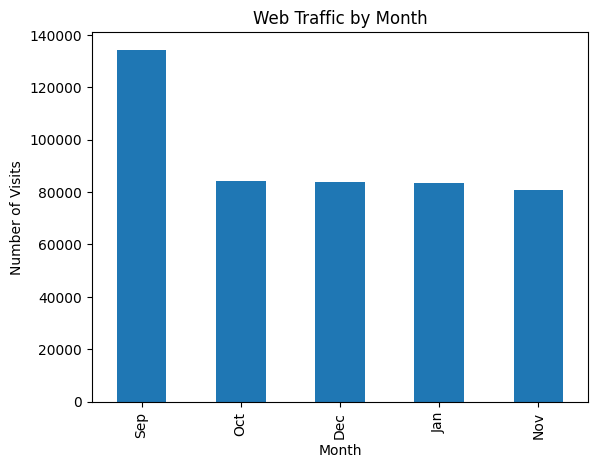

In [292]:
monthly_traffic = (
    logs_clean
    .groupby('Month')
    .size()
    .sort_values(
        ascending=False
    )
)

monthly_traffic

monthly_traffic.plot(
    kind='bar'
)

plt.title('Web Traffic by Month')
plt.xlabel('Month')
plt.ylabel('Number of Visits')
plt.show()

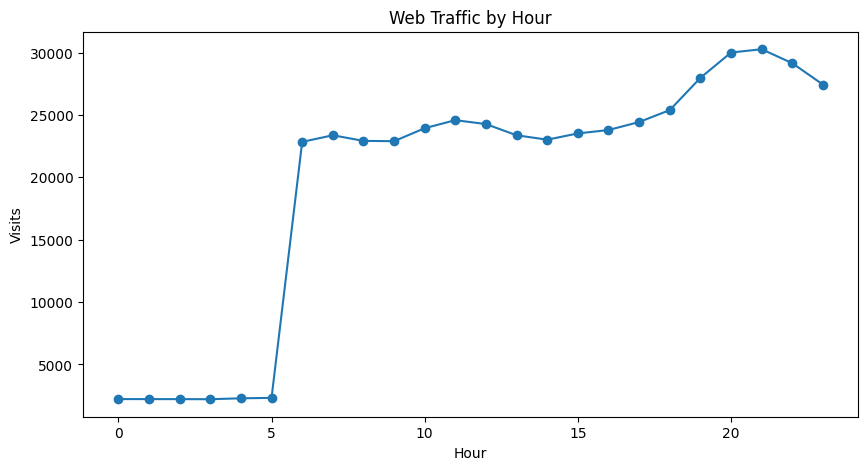

In [293]:
hourly_traffic = (
    logs_clean
    .groupby('Hour')
    .size()
)

hourly_traffic.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title('Web Traffic by Hour')
plt.xlabel('Hour')
plt.ylabel('Visits')
plt.show()



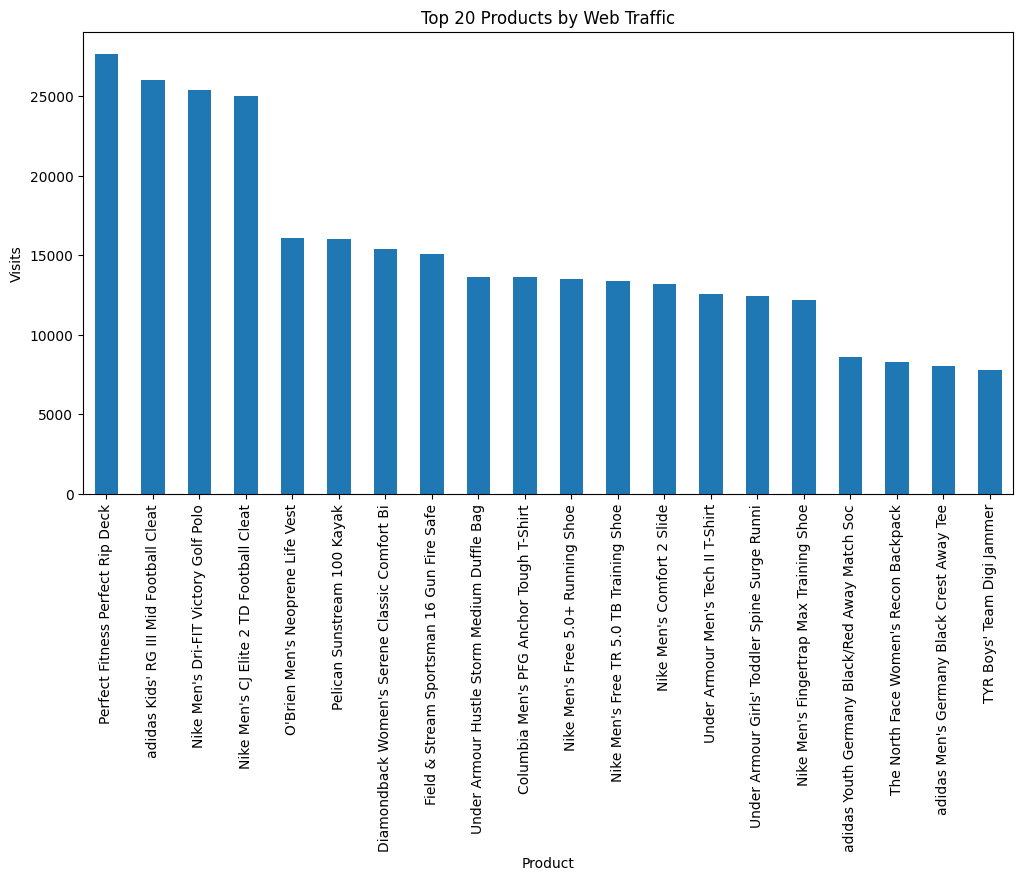

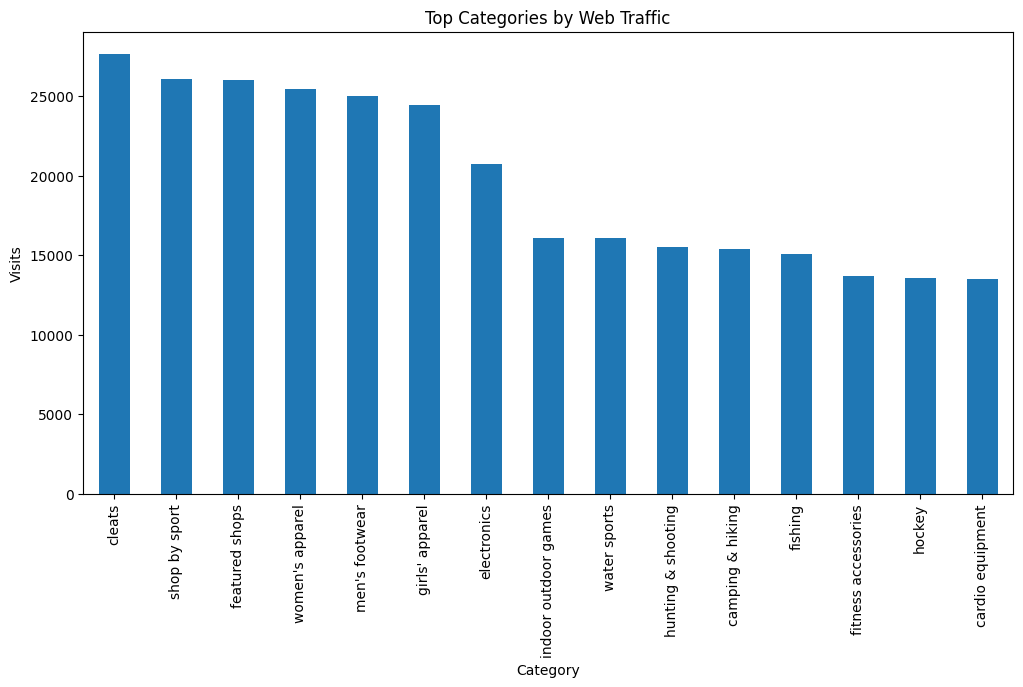

In [294]:
product_traffic = (
    logs_clean
    .groupby('Product')
    .size()
    .sort_values(
        ascending=False
    )
)

product_traffic.head(20)

product_traffic.head(20).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Top 20 Products by Web Traffic')
plt.xlabel('Product')
plt.ylabel('Visits')
plt.xticks(rotation=90)
plt.show()

category_traffic = (
    logs_clean
    .groupby('Category')
    .size()
    .sort_values(
        ascending=False
    )
)

category_traffic.head(15).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Top Categories by Web Traffic')
plt.ylabel('Visits')
plt.xticks(rotation=90)
plt.show()

In [295]:
department_traffic = (
    logs_clean
    .groupby('Department')
    .size()
    .sort_values(
        ascending=False
    )
)

department_traffic

unique_ips_by_product = (
    logs_clean
    .groupby('Product')['ip']
    .nunique()
    .sort_values(
        ascending=False
    )
)

unique_ips_by_product.head(20)

product_metadata = (
    logs_clean[
        [
            'Product',
            'Category',
            'Department'
        ]
    ]
    .drop_duplicates(
        subset=['Product']
    )
)

daily_visits = (
    logs_clean
    .groupby(
        [
            'DateOnly',
            'Product'
        ]
    )
    .size()
    .reset_index(
        name='Visits'
    )
)

daily_visits.head()

,DateOnly,Product,Visits
0,2017-09-01,Bag Boy Beverage Holder,3
1,2017-09-01,Bag Boy M330 Push Cart,8
2,2017-09-01,Bridgestone e6 Straight Distance NFL Carolina,4
3,2017-09-01,Bridgestone e6 Straight Distance NFL San Dieg,14
4,2017-09-01,Bridgestone e6 Straight Distance NFL Tennesse,6


In [296]:
all_dates = pd.date_range(
    start=logs_clean['DateOnly'].min(),
    end=logs_clean['DateOnly'].max(),
    freq='D'
)

all_products = (
    logs_clean['Product']
    .drop_duplicates()
    .tolist()
)

full_grid = pd.MultiIndex.from_product(
    [
        all_dates,
        all_products
    ],
    names=[
        'DateOnly',
        'Product'
    ]
).to_frame(
    index=False
)

daily_model = full_grid.merge(
    daily_visits,
    on=[
        'DateOnly',
        'Product'
    ],
    how='left'
)

daily_model['Visits'] = (
    daily_model['Visits']
    .fillna(0)
    .astype(int)
)


In [297]:
daily_model = daily_model.merge(
    product_metadata,
    on='Product',
    how='left'
)

daily_model = (
    daily_model
    .sort_values(
        [
            'Product',
            'DateOnly'
        ]
    )
    .reset_index(drop=True)
)

daily_model['Month'] = (
    daily_model['DateOnly']
    .dt.month
)

daily_model['DayOfWeek'] = (
    daily_model['DateOnly']
    .dt.dayofweek
)

daily_model['Weekend'] = (
    daily_model['DayOfWeek'] >= 5
).astype(int)

daily_model['DayOfMonth'] = (
    daily_model['DateOnly']
    .dt.day
)

daily_model['Visits_Lag_1'] = (
    daily_model
    .groupby('Product')['Visits']
    .shift(1)
)

daily_model['Visits_Lag_2'] = (
    daily_model
    .groupby('Product')['Visits']
    .shift(2)
)

daily_model['Visits_Lag_7'] = (
    daily_model
    .groupby('Product')['Visits']
    .shift(7)
)

In [299]:
daily_model['Rolling_Mean_3'] = (
    daily_model
    .groupby('Product')['Visits']
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            window=3,
            min_periods=1
        )
        .mean()
    )
)

daily_model['Rolling_Mean_7'] = (
    daily_model
    .groupby('Product')['Visits']
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            window=7,
            min_periods=1
        )
        .mean()
    )
)

daily_model['Rolling_Mean_14'] = (
    daily_model
    .groupby('Product')['Visits']
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            window=14,
            min_periods=1
        )
        .mean()
    )
)



In [300]:
daily_model['Rolling_Mean_14'] = (
    daily_model
    .groupby('Product')['Visits']
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            window=14,
            min_periods=1
        )
        .mean()
    )
)

daily_model['Rolling_Std_7'] = (
    daily_model
    .groupby('Product')['Visits']
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            window=7,
            min_periods=2
        )
        .std()
    )
)

daily_model['Next_Day_Visits'] = (
    daily_model
    .groupby('Product')['Visits']
    .shift(-1)
)

In [302]:
model_data = (
    daily_model
    .dropna(
        subset=[
            'Visits_Lag_1',
            'Visits_Lag_7',
            'Next_Day_Visits'
        ]
    )
    .copy()
)

In [303]:
model_data = (
    daily_model
    .dropna(
        subset=[
            'Visits_Lag_1',
            'Visits_Lag_7',
            'Next_Day_Visits'
        ]
    )
    .copy()
)

In [304]:
model_data[
    'Rolling_Std_7'
] = (
    model_data[
        'Rolling_Std_7'
    ]
    .fillna(0)
)

In [305]:
print(
    "Final modeling rows:",
    len(model_data)
)

model_data.head()

Final modeling rows: 11020


,DateOnly,Product,Visits,Category,Department,Month,DayOfWeek,Weekend,DayOfMonth,Visits_Lag_1,Visits_Lag_2,Visits_Lag_7,Rolling_Mean_3,Rolling_Mean_7,Rolling_Mean_14,Rolling_Std_7,Next_Day_Visits
7,2017-09-08,Bag Boy Beverage Holder,2,golf gloves,outdoors,9,4,0,8,2.0,9.0,3.0,4.666667,4.428571,4.428571,3.457222,4.0
8,2017-09-09,Bag Boy Beverage Holder,4,golf gloves,outdoors,9,5,1,9,2.0,2.0,9.0,4.333333,4.285714,4.125000,3.545621,14.0
9,2017-09-10,Bag Boy Beverage Holder,14,golf gloves,outdoors,9,6,1,10,4.0,2.0,0.0,2.666667,3.571429,4.111111,2.878492,10.0
10,2017-09-11,Bag Boy Beverage Holder,10,golf gloves,outdoors,9,0,0,11,14.0,4.0,5.0,6.666667,5.571429,5.100000,4.429339,9.0
11,2017-09-12,Bag Boy Beverage Holder,9,golf gloves,outdoors,9,1,0,12,10.0,14.0,3.0,9.333333,6.285714,5.545455,4.715728,9.0


In [306]:
categorical_features_logs = [
    'Product',
    'Category',
    'Department'
]

numerical_features_logs = [
    'Visits',
    'Visits_Lag_1',
    'Visits_Lag_2',
    'Visits_Lag_7',
    'Rolling_Mean_3',
    'Rolling_Mean_7',
    'Rolling_Mean_14',
    'Rolling_Std_7',
    'Month',
    'DayOfWeek',
    'Weekend',
    'DayOfMonth'
]

X_logs = model_data[
    categorical_features_logs +
    numerical_features_logs
]

y_logs = (
    model_data[
        'Next_Day_Visits'
    ]
)



In [307]:
print(
    model_data['DateOnly'].min(),
    model_data['DateOnly'].max()
)

train_mask_logs = (
    model_data['DateOnly']
    < '2018-01-01'
)

test_mask_logs = (
    model_data['DateOnly']
    >= '2018-01-01'
)

X_train_logs = (
    X_logs.loc[
        train_mask_logs
    ]
)

X_test_logs = (
    X_logs.loc[
        test_mask_logs
    ]
)

y_train_logs = (
    y_logs.loc[
        train_mask_logs
    ]
)

y_test_logs = (
    y_logs.loc[
        test_mask_logs
    ]
)

2017-09-08 00:00:00 2018-01-30 00:00:00


In [308]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [309]:
numeric_transformer_logs = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(
                strategy='median'
            )
        )
    ]
)

categorical_transformer_logs = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(
                strategy='most_frequent'
            )
        ),
        (
            'encoder',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)

preprocessor_logs = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer_logs,
            numerical_features_logs
        ),
        (
            'cat',
            categorical_transformer_logs,
            categorical_features_logs
        )
    ]
)



In [310]:
preprocessor_logs = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer_logs,
            numerical_features_logs
        ),
        (
            'cat',
            categorical_transformer_logs,
            categorical_features_logs
        )
    ]
)



In [311]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_regression(
    model_name,
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }

In [312]:
baseline_pred = (
    X_test_logs[
        'Visits'
    ].values
)

baseline_result = (
    evaluate_regression(
        'Naive Baseline',
        y_test_logs,
        baseline_pred
    )
)

baseline_result

from sklearn.linear_model import LinearRegression
linear_model = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor_logs
        ),
        (
            'regressor',
            LinearRegression()
        )
    ]
)

linear_model.fit(
    X_train_logs,
    y_train_logs
)

linear_pred = (
    linear_model.predict(
        X_test_logs
    )
)

linear_pred = np.maximum(
    linear_pred,
    0
)

linear_result = (
    evaluate_regression(
        'Linear Regression',
        y_test_logs,
        linear_pred
    )
)

linear_result

{'Model': 'Linear Regression',
 'MAE': 98.80814614029173,
 'RMSE': np.float64(99.55968612176981),
 'R2': -5.703501229036722}

In [314]:
from sklearn.tree import DecisionTreeRegressor

tree_reg_model = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor_logs
        ),

        (
            'regressor',
            DecisionTreeRegressor(
                max_depth=8,
                min_samples_leaf=10,
                random_state=42
            )
        )
    ]
)

tree_reg_model.fit(
    X_train_logs,
    y_train_logs
)

tree_reg_pred = (
    tree_reg_model.predict(
        X_test_logs
    )
)

tree_result = (
    evaluate_regression(
        'Decision Tree',
        y_test_logs,
        tree_reg_pred
    )
)

In [316]:
from sklearn.ensemble import RandomForestRegressor
rf_reg_model = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor_logs
        ),

        (
            'regressor',
            RandomForestRegressor(
                n_estimators=200,
                max_depth=14,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_reg_model.fit(
    X_train_logs,
    y_train_logs
)

rf_reg_pred = (
    rf_reg_model.predict(
        X_test_logs
    )
)

rf_result = (
    evaluate_regression(
        'Random Forest',
        y_test_logs,
        rf_reg_pred
    )
)

In [317]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor_logs
        ),

        (
            'regressor',
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=4,
                random_state=42
            )
        )
    ]
)

gb_model.fit(
    X_train_logs,
    y_train_logs
)

gb_pred = (
    gb_model.predict(
        X_test_logs
    )
)

gb_result = (
    evaluate_regression(
        'Gradient Boosting',
        y_test_logs,
        gb_pred
    )
)

In [319]:
!pip install -q xgboost

from xgboost import XGBRegressor

In [326]:
xgb_reg_model = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor_logs
        ),

        (
            'regressor',
            XGBRegressor(
                n_estimators=250,
                max_depth=5,
                learning_rate=0.05,

                subsample=0.8,
                colsample_bytree=0.8,

                objective='reg:squarederror',

                tree_method='hist',

                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


In [327]:
xgb_reg_model.fit(
    X_train_logs,
    y_train_logs
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Visits', 'Visits_Lag_1',
                                                   'Visits_Lag_2',
                                                   'Visits_Lag_7',
                                                   'Rolling_Mean_3',
                                                   'Rolling_Mean_7',
                                                   'Rolling_Mean_14',
                                                   'Rolling_Std_7', 'Month',
                                                   'DayOfWeek', 'Weekend',
                                                   'DayOfMonth']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=250, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [328]:
xgb_reg_pred = xgb_reg_model.predict(
    X_test_logs
)

xgb_reg_pred = np.maximum(
    xgb_reg_pred,
    0
)

In [330]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def forecast_metrics(
    name,
    actual,
    predicted
):

    actual = np.array(actual)
    predicted = np.array(predicted)

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    # WAPE
    wape = (
        np.sum(
            np.abs(
                actual - predicted
            )
        )
        /
        np.sum(
            np.abs(actual)
        )
        * 100
    )

    # SMAPE
    denominator = (
        np.abs(actual)
        +
        np.abs(predicted)
    )

    smape = np.mean(
        np.where(
            denominator == 0,
            0,
            2
            * np.abs(
                actual - predicted
            )
            / denominator
        )
    ) * 100

    return {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'WAPE_%': wape,
        'SMAPE_%': smape
    }

    xgb_result = forecast_metrics(
    'XGBoost',
    y_test_logs,
    xgb_reg_pred
)

xgb_result

{'Model': 'XGBoost Baseline',
 'Accuracy': 0.718794159208667,
 'Precision': 0.8359550561797753,
 'Recall': 0.6225941422594142,
 'F1': 0.7136690647482015,
 'ROC_AUC': np.float64(0.7792075458086856),
 'PR_AUC': np.float64(0.8462769067473306),
 'Brier_Score': np.float64(0.17990958299029639)}

In [331]:
rolling7_pred = (
    X_test_logs[
        'Rolling_Mean_7'
    ]
    .fillna(
        X_train_logs[
            'Rolling_Mean_7'
        ].median()
    )
    .values
)

rolling7_result = forecast_metrics(
    '7-Day Moving Average',
    y_test_logs,
    rolling7_pred
)

rolling7_result

{'Model': '7-Day Moving Average',
 'MAE': 7.4114661654135325,
 'RMSE': np.float64(10.225155458634369),
 'R2': 0.9292910326221708,
 'WAPE_%': np.float64(20.927270186066178),
 'SMAPE_%': np.float64(37.339453633751866)}

In [333]:
naive_pred = (
    X_test_logs[
        'Visits'
    ].values
)
naive_result = forecast_metrics(
    'Naive Previous-Day',
    y_test_logs,
    naive_pred
)

naive_result
quick_comparison = pd.DataFrame(
    [
        naive_result,
        rolling7_result,
        xgb_result
    ]
)

quick_comparison.sort_values(
    by='RMSE'
)


/tmp/ipykernel_1152/2651725668.py:58: RuntimeWarning: invalid value encountered in divide
  2


,Model,MAE,RMSE,R2,WAPE_%,SMAPE_%,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier_Score
1,7-Day Moving Average,7.411466,10.225155,0.929291,20.927270,37.339454,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Naive Previous-Day,9.676754,13.602518,0.874867,27.323616,48.297577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,XGBoost Baseline,NaN,NaN,NaN,NaN,NaN,0.718794,0.835955,0.622594,0.713669,0.779208,0.846277,0.17991


In [335]:
leakage_check = (
    daily_model
    .sort_values(
        [
            'Product',
            'DateOnly'
        ]
    )
    .copy()
)

In [336]:
leakage_check[
    'Expected_Lag1'
] = (
    leakage_check
    .groupby('Product')['Visits']
    .shift(1)
)

lag1_matches = np.isclose(
    leakage_check[
        'Visits_Lag_1'
    ].fillna(-9999),

    leakage_check[
        'Expected_Lag1'
    ].fillna(-9999)
).mean()

print(


    "Lag-1 correctness:",
    round(
        lag1_matches * 100,
        2
    ),
    "%"
)

Lag-1 correctness: 100.0 %


In [337]:
expected_rolling7 = (
    leakage_check
    .groupby('Product')['Visits']
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            window=7,
            min_periods=1
        )
        .mean()
    )
)

rolling_match = np.isclose(
    leakage_check[
        'Rolling_Mean_7'
    ].fillna(-9999),

    expected_rolling7
    .fillna(-9999)
).mean()

print(
    "Rolling-7 leakage check:",
    round(
        rolling_match * 100,
        2
    ),
    "%"
)



Rolling-7 leakage check: 100.0 %


In [339]:
dayofweek_summary = (
    model_data
    .groupby(
        'DayOfWeek'
    )['Visits']
    .agg(
        [
            'mean',
            'median',
            'sum'
        ]
    )
    .reset_index()
)

dayofweek_summary

,DayOfWeek,mean,median,sum
0,0,36.606516,20.0,58424
1,1,36.753759,20.0,58659
2,2,36.697368,20.0,55780
3,3,62.953289,22.0,95689
4,4,36.672932,20.0,58530
5,5,37.261278,21.0,59469
6,6,36.748747,20.0,58651


In [341]:
day_names = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

dayofweek_summary[
    'Day'
] = (
    dayofweek_summary[
        'DayOfWeek'
    ]
    .map(day_names)
)

dayofweek_summary

,DayOfWeek,mean,median,sum,Day
0,0,36.606516,20.0,58424,Monday
1,1,36.753759,20.0,58659,Tuesday
2,2,36.697368,20.0,55780,Wednesday
3,3,62.953289,22.0,95689,Thursday
4,4,36.672932,20.0,58530,Friday
5,5,37.261278,21.0,59469,Saturday
6,6,36.748747,20.0,58651,Sunday


In [340]:
day_names = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

dayofweek_summary[
    'Day'
] = (
    dayofweek_summary[
        'DayOfWeek'
    ]
    .map(day_names)
)

dayofweek_summary

,DayOfWeek,mean,median,sum,Day
0,0,36.606516,20.0,58424,Monday
1,1,36.753759,20.0,58659,Tuesday
2,2,36.697368,20.0,55780,Wednesday
3,3,62.953289,22.0,95689,Thursday
4,4,36.672932,20.0,58530,Friday
5,5,37.261278,21.0,59469,Saturday
6,6,36.748747,20.0,58651,Sunday


In [342]:
day_names = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

dayofweek_summary[
    'Day'
] = (
    dayofweek_summary[
        'DayOfWeek'
    ]
    .map(day_names)
)

dayofweek_summary

,DayOfWeek,mean,median,sum,Day
0,0,36.606516,20.0,58424,Monday
1,1,36.753759,20.0,58659,Tuesday
2,2,36.697368,20.0,55780,Wednesday
3,3,62.953289,22.0,95689,Thursday
4,4,36.672932,20.0,58530,Friday
5,5,37.261278,21.0,59469,Saturday
6,6,36.748747,20.0,58651,Sunday


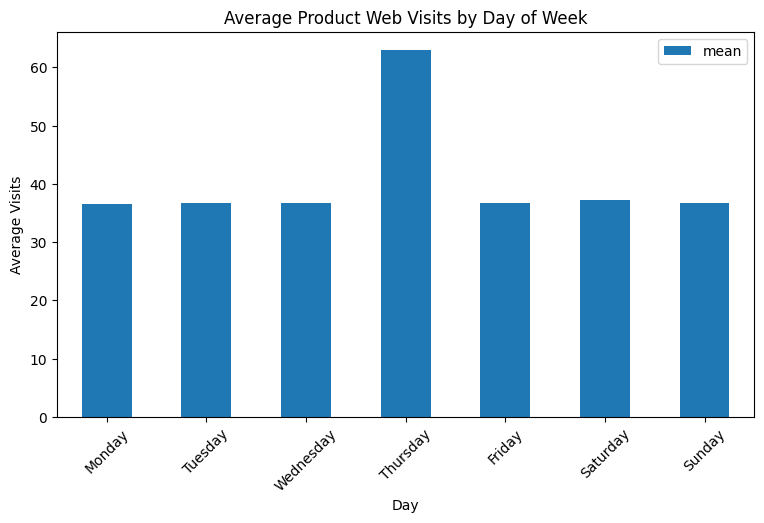

In [343]:
dayofweek_summary.plot(
    x='Day',
    y='mean',
    kind='bar',
    figsize=(9,5)
)

plt.title(
    'Average Product Web Visits by Day of Week'
)

plt.ylabel(
    'Average Visits'
)

plt.xticks(
    rotation=45
)

plt.show()

In [344]:
weekend_summary = (
    model_data
    .groupby(
        'Weekend'
    )['Visits']
    .agg(
        [
            'mean',
            'median',
            'sum'
        ]
    )
)

weekend_summary

,mean,median,sum
Weekend,,,
0,41.783597,20.0,327082
1,37.005013,20.0,118120


In [345]:
month_summary = (
    model_data
    .groupby('Month')['Visits']
    .agg(
        [
            'mean',
            'median',
            'sum'
        ]
    )
)

month_summary

,mean,median,sum
Month,,,
1,35.419298,20.0,80756
9,66.100114,25.0,115543
10,35.727929,20.0,84175
11,35.419298,20.0,80756
12,35.641766,20.0,83972


In [346]:
forecast_results = (
    model_data.loc[
        test_mask_logs,
        [
            'DateOnly',
            'Product',
            'Category',
            'Department',
            'Visits',
            'Next_Day_Visits'
        ]
    ]
    .copy()
)

In [347]:
forecast_results[
    'Predicted_Next_Day_Visits'
] = xgb_reg_pred

forecast_results[
    'Error'
] = (
    forecast_results[
        'Next_Day_Visits'
    ]
    -
    forecast_results[
        'Predicted_Next_Day_Visits'
    ]
)

forecast_results[
    'Absolute_Error'
] = np.abs(
    forecast_results[
        'Error'
    ]
)

In [349]:
product_error_analysis = (
    forecast_results
    .groupby('Product')
    .agg(
        Records=(
            'Product',
            'size'
        ),

        Actual_Average=(
            'Next_Day_Visits',
            'mean'
        ),

        Predicted_Average=(
            'Predicted_Next_Day_Visits',
            'mean'
        ),

        MAE=(
            'Absolute_Error',
            'mean'
        )
    )
    .reset_index()
)

product_error_analysis.sort_values(
    by='MAE',
    ascending=False
).head(15)

product_error_analysis.sort_values(
    by='MAE'
).head(15)

,Product,Records,Actual_Average,Predicted_Average,MAE
50,TaylorMade 2017 Purelite Stand Bag,30,6.233333,11.905363,7.617470
55,Team Golf Texas Longhorns Putter Grip,30,8.000000,14.263203,7.760233
52,Team Golf Pittsburgh Steelers Putter Grip,30,6.666667,13.007943,7.761686
17,Garmin Forerunner 910XT GPS Watch,30,4.666667,10.154384,7.793686
1,Bag Boy M330 Push Cart,30,5.666667,11.187075,7.890583
8,Clicgear 8.0 Shoe Brush,30,8.900000,14.423354,7.918058
14,Fitbit The One Wireless Activity & Sleep Trac,30,4.533333,10.314100,7.940233
58,Titleist Pro V1x Golf Balls,30,6.866667,13.202641,8.006029
3,Bridgestone e6 Straight Distance NFL San Dieg,30,7.433333,13.870350,8.028123
31,Mio ALPHA Heart Rate Monitor/Sport Watch,30,5.833333,11.665730,8.196779


In [350]:
category_error_analysis = (
    forecast_results
    .groupby('Category')
    .agg(
        Records=(
            'Category',
            'size'
        ),

        Actual_Average=(
            'Next_Day_Visits',
            'mean'
        ),

        Predicted_Average=(
            'Predicted_Next_Day_Visits',
            'mean'
        ),

        MAE=(
            'Absolute_Error',
            'mean'
        )
    )
    .reset_index()
)

category_error_analysis.sort_values(
    by='MAE',
    ascending=False
).head(15)

,Category,Records,Actual_Average,Predicted_Average,MAE
23,men's footwear,30,146.600000,305.515808,165.426961
31,women's apparel,30,145.766667,287.362915,149.283465
9,featured shops,30,152.300000,277.427460,137.198940
7,cleats,30,157.900000,256.520660,102.890768
30,water sports,30,91.766667,167.624374,84.917528
6,cardio equipment,30,78.866667,154.783524,83.438080
5,camping & hiking,30,88.033333,166.317780,81.269306
1,as seen on tv!,30,75.900000,143.878967,80.838180
20,indoor outdoor games,30,91.233333,164.130325,76.754152
10,fishing,30,86.233333,159.618515,76.018427


In [351]:
train_predictions = (
    xgb_reg_model
    .predict(
        X_train_logs
    )
)

train_predictions = np.maximum(
    train_predictions,
    0
)

train_residuals = (
    np.array(
        y_train_logs
    )
    -
    train_predictions
)

In [353]:
lower_error = np.quantile(
    train_residuals,
    0.05
)

upper_error = np.quantile(
    train_residuals,
    0.95
)

print(
    "Residual lower:",
    lower_error
)

print(
    "Residual upper:",
    upper_error
)
forecast_results[
    'Prediction_Lower_90'
] = np.maximum(
    forecast_results[
        'Predicted_Next_Day_Visits'
    ]
    + lower_error,
    0
)


Residual lower: -13.290565586090088
Residual upper: 14.395909881591797


In [354]:
forecast_results[
    'Prediction_Upper_90'
] = np.maximum(
    forecast_results[
        'Predicted_Next_Day_Visits'
    ]
    + upper_error,
    0
)

In [355]:
inside_interval = (
    (
        forecast_results[
            'Next_Day_Visits'
        ]
        >=
        forecast_results[
            'Prediction_Lower_90'
        ]
    )
    &
    (
        forecast_results[
            'Next_Day_Visits'
        ]
        <=
        forecast_results[
            'Prediction_Upper_90'
        ]
    )
)

coverage = (
    inside_interval.mean()
    * 100
)

print(
    "Approximate 90% interval coverage:",
    round(
        coverage,
        2
    ),
    "%"
)

Approximate 90% interval coverage: 67.63 %


In [358]:
low_cut = (
    y_train_logs
    .quantile(0.33)
)

high_cut = (
    y_train_logs
    .quantile(0.67)
)

print(
    "Low/Medium cutoff:",
    low_cut
)

print(
    "Medium/High cutoff:",
    high_cut
)

def demand_level(value):

    if value <= low_cut:
        return 'Low Demand'

    elif value <= high_cut:
        return 'Medium Demand'

    else:
        return 'High Demand'

        forecast_results[
    'Demand_Level'
] = (
    forecast_results[
        'Predicted_Next_Day_Visits'
    ]
    .apply(
        demand_level
    )
)



Low/Medium cutoff: 11.0
Medium/High cutoff: 40.0


In [360]:
forecast_results[
    'Demand_Level'
] = (
    forecast_results[
        'Predicted_Next_Day_Visits'
    ]
    .apply(
        demand_level
    )
)

forecast_results[
    'Demand_Level'
].value_counts()

,count
Demand_Level,
High Demand,876
Low Demand,746
Medium Demand,658


In [361]:
forecast_results[
    'Stock_Attention_Flag'
] = np.where(
    forecast_results[
        'Demand_Level'
    ] == 'High Demand',

    'Review Stock',

    'Normal'
)

In [362]:
forecast_results[
    'Stock_Attention_Flag'
].value_counts()

,count
Stock_Attention_Flag,
Normal,1404
Review Stock,876


In [363]:
product_demand_summary = (
    forecast_results
    .groupby('Product')
    .agg(
        Average_Actual_Demand=(
            'Next_Day_Visits',
            'mean'
        ),

        Average_Predicted_Demand=(
            'Predicted_Next_Day_Visits',
            'mean'
        ),

        Maximum_Predicted_Demand=(
            'Predicted_Next_Day_Visits',
            'max'
        ),

        Average_MAE=(
            'Absolute_Error',
            'mean'
        )
    )
    .reset_index()
)

top_demand_products = (
    product_demand_summary
    .sort_values(
        by='Average_Predicted_Demand',
        ascending=False
    )
)

top_demand_products.head(20)

,Product,Average_Actual_Demand,Average_Predicted_Demand,Maximum_Predicted_Demand,Average_MAE
33,Nike Men's CJ Elite 2 TD Football Cleat,146.600000,305.515808,1409.430054,165.426961
35,Nike Men's Dri-FIT Victory Golf Polo,145.766667,287.362915,1353.445923,149.283465
72,adidas Kids' RG III Mid Football Cleat,152.300000,277.427460,1456.218994,137.198940
43,Perfect Fitness Perfect Rip Deck,157.900000,256.520660,1679.421387,102.890768
42,Pelican Sunstream 100 Kayak,91.766667,167.624374,980.664001,84.917528
12,Diamondback Women's Serene Classic Comfort Bi,88.033333,166.317780,947.316650,81.269306
40,O'Brien Men's Neoprene Life Vest,91.233333,164.130325,940.455872,76.754152
13,Field & Stream Sportsman 16 Gun Fire Safe,86.233333,159.618515,942.885132,76.018427
37,Nike Men's Free 5.0+ Running Shoe,78.866667,154.783524,875.041809,83.438080
10,Columbia Men's PFG Anchor Tough T-Shirt,77.833333,145.989731,849.832458,76.904857


In [364]:
category_demand_summary = (
    forecast_results
    .groupby('Category')
    .agg(
        Total_Actual_Demand=(
            'Next_Day_Visits',
            'sum'
        ),

        Total_Predicted_Demand=(
            'Predicted_Next_Day_Visits',
            'sum'
        ),

        Average_Error=(
            'Absolute_Error',
            'mean'
        )
    )
    .reset_index()
)

department_demand_summary = (
    forecast_results
    .groupby('Department')
    .agg(
        Total_Actual_Demand=(
            'Next_Day_Visits',
            'sum'
        ),

        Total_Predicted_Demand=(
            'Predicted_Next_Day_Visits',
            'sum'
        ),

        Average_Error=(
            'Absolute_Error',
            'mean'
        )
    )
    .reset_index()
)

final_forecasting_comparison = pd.DataFrame(
    [
        naive_result,
        rolling7_result,
        xgb_result
    ]
)

In [365]:
final_forecasting_comparison.sort_values(
    by='RMSE'
)

,Model,MAE,RMSE,R2,WAPE_%,SMAPE_%,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier_Score
1,7-Day Moving Average,7.411466,10.225155,0.929291,20.927270,37.339454,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Naive Previous-Day,9.676754,13.602518,0.874867,27.323616,48.297577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,XGBoost Baseline,NaN,NaN,NaN,NaN,NaN,0.718794,0.835955,0.622594,0.713669,0.779208,0.846277,0.17991


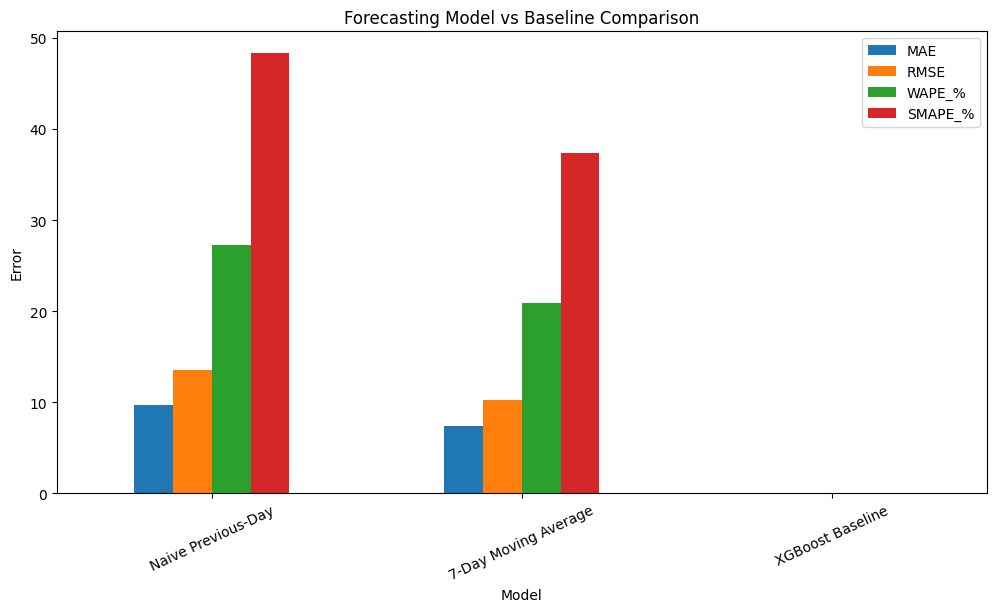

In [366]:
final_forecasting_comparison.set_index(
    'Model'
)[
    [
        'MAE',
        'RMSE',
        'WAPE_%',
        'SMAPE_%'
    ]
].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
    'Forecasting Model vs Baseline Comparison'
)

plt.ylabel(
    'Error'
)

plt.xticks(
    rotation=25
)

plt.show()

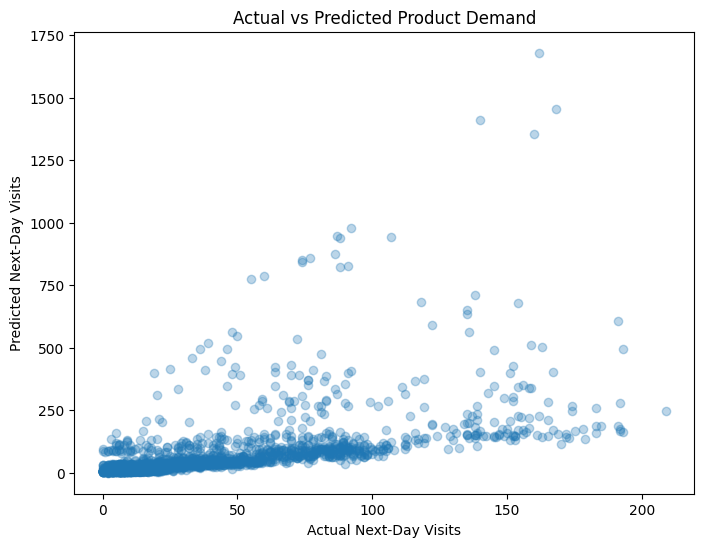

In [367]:
plt.figure(
    figsize=(8,6)
)

plt.scatter(
    forecast_results[
        'Next_Day_Visits'
    ],

    forecast_results[
        'Predicted_Next_Day_Visits'
    ],

    alpha=0.3
)

plt.xlabel(
    'Actual Next-Day Visits'
)

plt.ylabel(
    'Predicted Next-Day Visits'
)

plt.title(
    'Actual vs Predicted Product Demand'
)

plt.show()

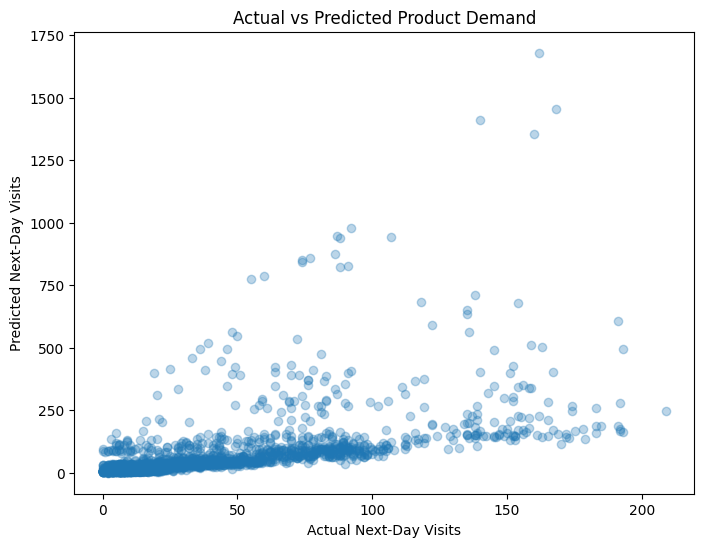

In [368]:
plt.figure(
    figsize=(8,6)
)

plt.scatter(
    forecast_results[
        'Next_Day_Visits'
    ],

    forecast_results[
        'Predicted_Next_Day_Visits'
    ],

    alpha=0.3
)

plt.xlabel(
    'Actual Next-Day Visits'
)

plt.ylabel(
    'Predicted Next-Day Visits'
)

plt.title(
    'Actual vs Predicted Product Demand'
)

plt.show()

In [369]:
example_product = (
    product_demand_summary
    .sort_values(
        'Average_Predicted_Demand',
        ascending=False
    )
    .iloc[0][
        'Product'
    ]
)

print(
    "Example product:",
    example_product
)

Example product: Nike Men's CJ Elite 2 TD Football Cleat


In [370]:
example_data = (
    forecast_results[
        forecast_results[
            'Product'
        ]
        == example_product
    ]
    .sort_values(
        'DateOnly'
    )
)

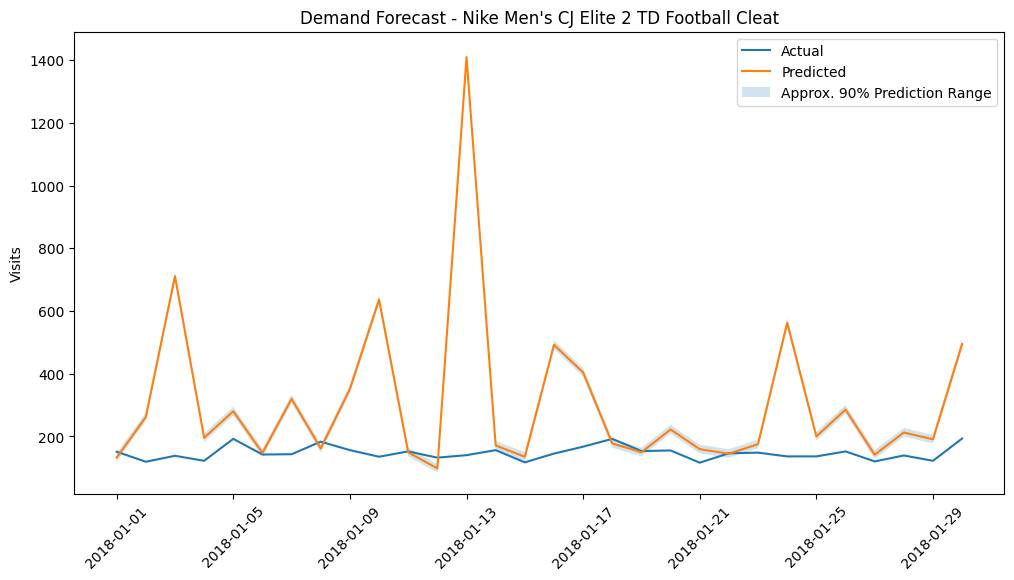

In [371]:
plt.figure(
    figsize=(12,6)
)

plt.plot(
    example_data[
        'DateOnly'
    ],

    example_data[
        'Next_Day_Visits'
    ],

    label='Actual'
)

plt.plot(
    example_data[
        'DateOnly'
    ],

    example_data[
        'Predicted_Next_Day_Visits'
    ],

    label='Predicted'
)

plt.fill_between(
    example_data[
        'DateOnly'
    ],

    example_data[
        'Prediction_Lower_90'
    ],

    example_data[
        'Prediction_Upper_90'
    ],

    alpha=0.2,

    label='Approx. 90% Prediction Range'
)

plt.xticks(
    rotation=45
)

plt.ylabel(
    'Visits'
)

plt.title(
    f'Demand Forecast - {example_product}'
)

plt.legend()

plt.show()

In [372]:
trained_preprocessor_logs = (
    xgb_reg_model
    .named_steps[
        'preprocessor'
    ]
)

In [373]:
encoded_names_logs = (
    trained_preprocessor_logs
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(
        categorical_features_logs
    )
)

In [374]:
all_feature_names_logs = (
    numerical_features_logs
    +
    list(
        encoded_names_logs
    )
)

In [375]:
trained_xgb_logs = (
    xgb_reg_model
    .named_steps[
        'regressor'
    ]
)

In [377]:
feature_importance_logs = (
    pd.DataFrame({
        'Feature':
            all_feature_names_logs,

        'Importance':
            trained_xgb_logs
            .feature_importances_
    })
    .sort_values(
        by='Importance',
        ascending=False
    )
)
feature_importance_logs.head(20)

,Feature,Importance
11,DayOfMonth,0.236594
4,Rolling_Mean_3,0.099914
6,Rolling_Mean_14,0.097037
121,Department_apparel,0.084714
126,Department_outdoors,0.079494
5,Rolling_Mean_7,0.068711
9,DayOfWeek,0.063503
8,Month,0.061440
2,Visits_Lag_2,0.028507
3,Visits_Lag_7,0.017330


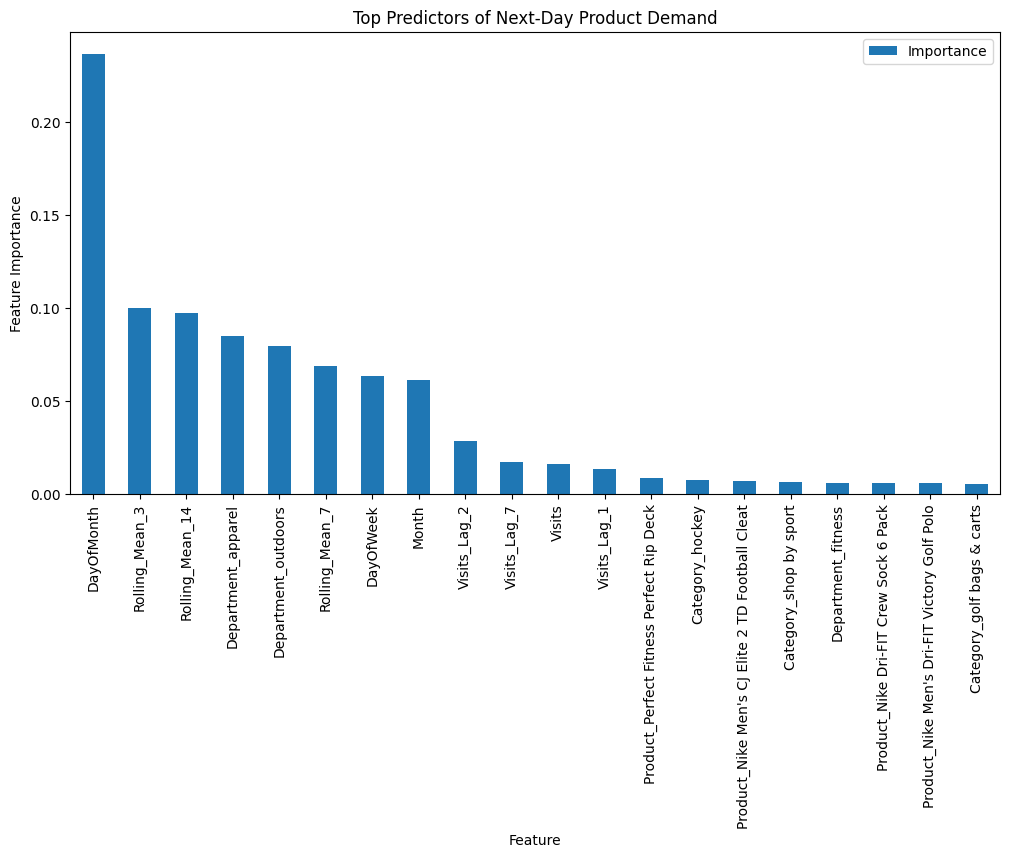

In [378]:
feature_importance_logs.head(20).plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(12,6)
)

plt.title(
    'Top Predictors of Next-Day Product Demand'
)

plt.ylabel(
    'Feature Importance'
)

plt.xticks(
    rotation=90
)

plt.show()

In [379]:
!pip install -q shap

import shap

X_test_transformed_logs = (
    trained_preprocessor_logs
    .transform(
        X_test_logs
    )
)

In [380]:
sample_size = min(
    200,
    X_test_transformed_logs.shape[0]
)

X_shap_logs = (
    X_test_transformed_logs[
        :sample_size
    ]
)

In [383]:
if hasattr(
    X_shap_logs,
    'toarray'
):
    X_shap_logs = (
        X_shap_logs
        .toarray()
    )

In [384]:
explainer_logs = shap.TreeExplainer(
    trained_xgb_logs
)

shap_values_logs = (
    explainer_logs
    .shap_values(
        X_shap_logs
    )
)

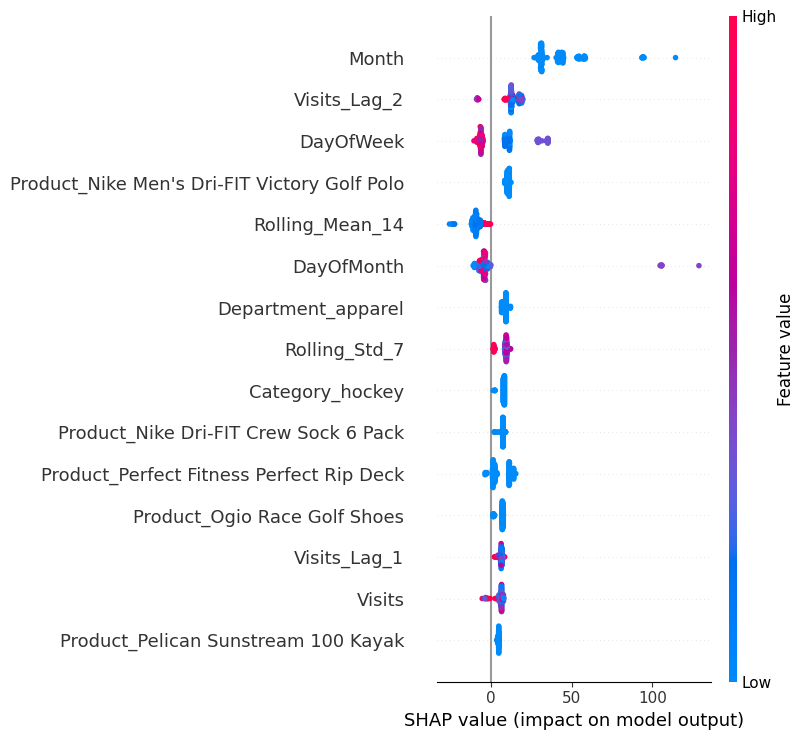

In [385]:
shap.summary_plot(
    shap_values_logs,
    X_shap_logs,
    feature_names=
        all_feature_names_logs,
    max_display=15
)

In [386]:
forecast_results.to_csv(
    'AccessLogs_Final_Advanced_Forecast.csv',
    index=False
)

In [387]:
final_forecasting_comparison.to_csv(
    'AccessLogs_Final_Model_Comparison.csv',
    index=False
)

In [388]:
product_error_analysis.to_csv(
    'AccessLogs_Product_Error_Analysis.csv',
    index=False
)

In [391]:
category_error_analysis.to_csv(
    'AccessLogs_Category_Error_Analysis.csv',
    index=False
)

In [392]:
product_demand_summary.to_csv(
    'AccessLogs_Product_Demand_Summary.csv',
    index=False
)

In [393]:
category_demand_summary.to_csv(
    'AccessLogs_Category_Demand_Summary.csv',
    index=False
)

In [394]:
department_demand_summary.to_csv(
    'AccessLogs_Department_Demand_Summary.csv',
    index=False
)

In [395]:
department_demand_summary.to_csv(
    'AccessLogs_Department_Demand_Summary.csv',
    index=False
)

In [397]:
dayofweek_summary.to_csv(
    'AccessLogs_DayOfWeek_Seasonality.csv',
    index=False
)

feature_importance_logs.to_csv(
    'AccessLogs_Feature_Importance.csv',
    index=False
)

In [398]:
import joblib

joblib.dump(
    xgb_reg_model,
    'AccessLogs_Final_XGBoost_Demand_Model.pkl'
)

['AccessLogs_Final_XGBoost_Demand_Model.pkl']

In [399]:
model_data.to_csv(
    'AccessLogs_Final_Demand_Modeling_Dataset.csv',
    index=False
)

In [400]:
import os

final_files = [

    'AccessLogs_Final_Advanced_Forecast.csv',

    'AccessLogs_Final_Model_Comparison.csv',

    'AccessLogs_Product_Error_Analysis.csv',

    'AccessLogs_Category_Error_Analysis.csv',

    'AccessLogs_Product_Demand_Summary.csv',

    'AccessLogs_Category_Demand_Summary.csv',

    'AccessLogs_Department_Demand_Summary.csv',

    'AccessLogs_DayOfWeek_Seasonality.csv',

    'AccessLogs_Feature_Importance.csv',

    'AccessLogs_Final_XGBoost_Demand_Model.pkl',

    'AccessLogs_Final_Demand_Modeling_Dataset.csv'
]

for file in final_files:

    print(
        file,
        "->",
        os.path.exists(file)
    )

AccessLogs_Final_Advanced_Forecast.csv -> True
AccessLogs_Final_Model_Comparison.csv -> True
AccessLogs_Product_Error_Analysis.csv -> True
AccessLogs_Category_Error_Analysis.csv -> True
AccessLogs_Product_Demand_Summary.csv -> True
AccessLogs_Category_Demand_Summary.csv -> True
AccessLogs_Department_Demand_Summary.csv -> True
AccessLogs_DayOfWeek_Seasonality.csv -> True
AccessLogs_Feature_Importance.csv -> True
AccessLogs_Final_XGBoost_Demand_Model.pkl -> True
AccessLogs_Final_Demand_Modeling_Dataset.csv -> True


In [401]:
from google.colab import files

In [402]:
files.download(
    'AccessLogs_Final_Advanced_Forecast.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [403]:
files.download(
    'AccessLogs_Final_Model_Comparison.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [404]:
files.download(
    'AccessLogs_Final_XGBoost_Demand_Model.pkl'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>